## Step 4: The TESS Labeling Factory (Object-Oriented Manual Classifier)

This is the big one — a fully object-oriented rewrite of the manual labeling workflow from the Kepler pipeline (`01_dataset_1.ipynb`), except now built around a `TESSDataProcessor` class instead of loose functions, and with noticeably more polish: retry logic, richer diagnostics, six-panel plots, and duplicate-proofing baked in from the start.

**Why a class this time?** The Kepler version tracked state (which files are labeled, current progress, etc.) through loose variables and CSV re-reads. Here, all of that state — processed IDs, failed IDs, running tallies, current position in the list — lives as attributes on a single `TESSDataProcessor` object, making the whole thing easier to reason about and extend.

**The Algorithm, broken down by responsibility:**

**State & bookkeeping**
- On `__init__`, the processor immediately loads any previously **failed IDs** (`failed_ids.csv`) and **processed IDs with labels** (`processed_ids.csv`) — so a fresh run of this notebook automatically knows what's already been dealt with, no separate "resume?" prompt needed like in Notebook 2's ID checker.
- `is_duplicate()` checks a candidate ID against both the processed set and failed list before doing any expensive work on it.
- `load_tess_ids()` reads `new_tess_id.csv` (output of Notebook 1), lower-cases column names defensively, filters out anything already processed/failed, and reports exactly how many *new* IDs are available.

**Data acquisition — `download_tess_data_with_lightkurve()`**
- Wraps the TIC number safely (catching bad formats early).
- **Retries up to 2 times** with a short `time.sleep(2)` pause between attempts — a small but meaningful robustness upgrade over Notebook 2's single-shot download, since flaky network calls to MAST are a real occurrence, not a hypothetical.
- Validates that the returned light curve actually has data (`len(lc.time) != 0`) and enough valid points (`< 10` valid rows is treated as a failure) before accepting it.
- Any failure along the way — no search results, no download, insufficient points, or an exception — automatically appends the ID to `failed_ids` and immediately persists it to `failed_ids.csv`, so failures are never lost even if the notebook crashes two IDs later.

**Signal processing — near-identical logic to earlier notebooks, reused here**
- `normalize_flux()` — the same z-score normalization pattern seen in the Kepler `dataset_1` notebook.
- `flatten_lc()` — a more defensive version of the Savitzky-Golay detrending from before: it first does a **3-sigma outlier clip** on the input before fitting the trend (reducing the chance that a single cosmic-ray spike distorts the whole fit), then adaptively shrinks the filter window if there isn't enough data, with the same graceful fallback to simple median-subtraction if `savgol_filter` throws.

**Visualization — this is where it gets genuinely thorough**
- `diagnose_detrending()` produces a **2×2 diagnostic grid**: normalized flux, the fitted trend, the detrended result, and all three overlaid together — plus printed statistics (mean/std of normalized vs. detrended flux) and an automatic verdict ("Detrending appears successful" vs. "may not be optimal") based on how close the detrended mean lands to zero.
- `plot_all_light_curves()` generates **up to six separate figures** per star: raw flux, normalized+trend, detrended — each duplicated for both regular flux and SAP flux if they differ (`not np.array_equal(sap_flux, flux)`), with annotated info boxes showing the TESS ID and time range directly on the plot.
- `plot_zoomed_transit()` **automatically finds the deepest dip** (`np.nanargmin(flux)`) rather than requiring a hardcoded transit center like Notebook 3 did — a genuinely nice upgrade, since it means the zoom-in works for *any* star without manual tuning.

**The interactive labeling loop**
- `get_user_classification()` presents the same five-option menu as the Kepler labeling notebook (Positive / Negative / Uncertain / Skip / Stop), but here it also updates the processor's internal counters (`self.positive_transits`, etc.) and immediately persists both the classification CSV (via `append_to_csv()`) *and* the running `processed_ids.csv` — so progress is saved continuously, not just at the end of a batch.
- `run_processing()` orchestrates the full session: asks how many IDs to process initially, works through them one at a time via `process_single_tess_id()`, shows a running summary (`show_summary()`), then loops via `ask_add_more_data()` — letting you process more IDs in additional rounds without restarting the notebook, until you explicitly choose to stop.

**Output:** Four label CSVs (`Positive_Transit.csv`, `Negative_Transit.csv`, `Uncertain_Transit.csv`, `Skipped_Transit.csv`), plus `failed_ids.csv` and `processed_ids.csv` for tracking/resuming — feeding directly into `02_d_CNN_LSTM.ipynb`.

*TL;DR: this is Notebook 3's Kepler labeling script, except it went to business school, got a class structure, added retry logic, and now makes six plots per star instead of three.*

In [1]:
import pandas as pd
import numpy as np
import traceback
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import time
import os
import warnings
import csv

warnings.filterwarnings('ignore')

In [2]:
import lightkurve as lk

In [3]:
class TESSDataProcessor:
    def __init__(self, tess_ids_file):
        self.tess_ids_file = tess_ids_file
        self.processed_data = []
        self.tess_ids = []
        self.total_ids = 0
        self.positive_transits = 0
        self.negative_transits = 0
        self.uncertain_transits = 0
        self.current_index = 0
        self.total_processed = 0
        self.failed_ids = []
        self.processed_ids_set = set()
        self.processed_labels = {}
        self.failed_csv = "failed_ids.csv"
        self.processed_csv = "processed_ids.csv"
        
        self.load_failed_ids()
        self.load_processed_ids()
        
    def load_failed_ids(self):
        if os.path.exists(self.failed_csv):
            try:
                df = pd.read_csv(self.failed_csv)
                if 'tess_id' in df.columns:
                    self.failed_ids = df['tess_id'].astype(str).tolist()
                    print(f"Loaded {len(self.failed_ids)} previously failed IDs")
            except Exception as e:
                print(f"Warning: Could not load {self.failed_csv}: {str(e)}")
    
    def load_processed_ids(self):
        if os.path.exists(self.processed_csv):
            try:
                df = pd.read_csv(self.processed_csv)
                if 'tess_id' in df.columns:
                    ids = df['tess_id'].astype(str).tolist()
                    self.processed_ids_set = set(ids)
                    if 'label' in df.columns:
                        labels = df['label'].astype(str).tolist()
                        self.processed_labels = dict(zip(ids, labels))
                    else:
                        self.processed_labels = {tid: 'unknown' for tid in ids}
                    print(f"Loaded {len(self.processed_ids_set)} previously processed IDs with labels")
            except Exception as e:
                print(f"Warning: Could not load {self.processed_csv}: {str(e)}")
    
    def save_processed_ids(self):
        try:
            df = pd.DataFrame({
                'tess_id': list(self.processed_ids_set),
                'label': [self.processed_labels.get(tid, 'unknown') for tid in self.processed_ids_set]
            })
            df.to_csv(self.processed_csv, index=False)
        except Exception as e:
            print(f"Error saving processed IDs: {str(e)}")
    
    def save_failed_ids(self):
        try:
            df = pd.DataFrame({'tess_id': self.failed_ids})
            df.to_csv(self.failed_csv, index=False)
        except Exception as e:
            print(f"Error saving failed IDs: {str(e)}")
    
    def is_duplicate(self, tess_id):
        return tess_id in self.processed_ids_set or tess_id in self.failed_ids
    
    def load_tess_ids(self):
        try:
            df = pd.read_csv(self.tess_ids_file)
            df.columns = df.columns.str.lower()
            if 'tess_id' not in df.columns:
                print(f"Error: 'tess_id' column not found.")
                print(f"Available columns: {df.columns.tolist()}")
                return False
            all_ids = df['tess_id'].dropna().astype(str).tolist()
            self.tess_ids = []
            duplicate_count = 0
            for tess_id in all_ids:
                if not self.is_duplicate(tess_id):
                    self.tess_ids.append(tess_id)
                else:
                    duplicate_count += 1
            self.total_ids = len(self.tess_ids)
            print(f"Total TESS IDs found in file: {len(all_ids)}")
            print(f"IDs already processed/failed (skipped): {duplicate_count}")
            print(f"New IDs available for processing: {self.total_ids}")
            if self.total_ids > 0:
                print(f"First 5 new IDs: {self.tess_ids[:5]}")
            return True
        except Exception as e:
            print(f"Error loading TESS IDs: {str(e)}")
            return False
    
    def get_user_input_number(self, prompt, min_val=0, max_val=None):
        while True:
            try:
                user_input = input(prompt)
                num = int(user_input)
                if num < min_val:
                    print(f"Please enter a number >= {min_val}")
                    continue
                if max_val is not None and num > max_val:
                    print(f"Please enter a number <= {max_val}")
                    continue
                return num
            except ValueError:
                print("Please enter a valid number")
    
    def download_tess_data_with_lightkurve(self, tess_id, retry_count=2):
        try:
            tic_number = int(float(tess_id))
        except ValueError:
            print(f"Invalid TIC number format: {tess_id}")
            return None
        
        tic_query = f"TIC {tic_number}"
        print(f"  Searching for {tic_query} using lightkurve...")
        
        for attempt in range(retry_count):
            try:
                search_result = lk.search_lightcurve(tic_query, mission="TESS")
                if len(search_result) == 0:
                    print(f"  No TESS observations found for {tic_query}")
                    if tess_id not in self.failed_ids:
                        self.failed_ids.append(tess_id)
                        self.save_failed_ids()
                    return None
                print(f"  Found {len(search_result)} sectors for {tic_query}")
                lc = search_result.download()
                if lc is None or len(lc.time) == 0:
                    print(f"  Failed to download light curve for {tic_query}")
                    if tess_id not in self.failed_ids:
                        self.failed_ids.append(tess_id)
                        self.save_failed_ids()
                    return None
                flux_data = lc.flux.value
                time_data = lc.time.value
                mask = np.isfinite(time_data) & np.isfinite(flux_data)
                time_data = time_data[mask]
                flux_data = flux_data[mask]
                flux_data = flux_data.astype(np.float64)
                if len(time_data) < 10:
                    print(f"  Insufficient valid data points for {tic_query}")
                    if tess_id not in self.failed_ids:
                        self.failed_ids.append(tess_id)
                        self.save_failed_ids()
                    return None
                time_min = np.min(time_data)
                time_max = np.max(time_data)
                time_median = np.median(time_data)
                print(f"  Successfully downloaded data for {tic_query}")
                print(f"    Points: {len(time_data)}")
                print(f"    Time range: {time_min:.2f} to {time_max:.2f} (BJD - 2454833)")
                print(f"    Median time: {time_median:.2f}")
                return {
                    'time': time_data,
                    'flux': flux_data,
                    'tess_id': tess_id,
                    'tic_number': tic_number,
                    'lightcurve': lc,
                    'btjd': time_median,
                    'time_min': time_min,
                    'time_max': time_max
                }
            except Exception as e:
                print(f"  Attempt {attempt + 1} failed: {str(e)}")
                if attempt < retry_count - 1:
                    print(f"  Retrying...")
                    time.sleep(2)
                else:
                    if tess_id not in self.failed_ids:
                        self.failed_ids.append(tess_id)
                        self.save_failed_ids()
                    return None
        return None
    
    def normalize_flux(self, flux):
        mask = np.isfinite(flux)
        flux_clean = flux[mask]
        if len(flux_clean) == 0:
            return flux
        normalized = np.full_like(flux, np.nan)
        normalized[mask] = (flux_clean - np.mean(flux_clean)) / np.std(flux_clean)
        return normalized
    
    def flatten_lc(self, time_data, flux, window_length=401, polyorder=2):
        mask = np.isfinite(flux)
        flux_clean = flux[mask]
        time_clean = time_data[mask]
        if len(flux_clean) < 10:
            return np.ones_like(flux), flux
        median = np.median(flux_clean)
        std = np.std(flux_clean)
        outlier_mask = np.abs(flux_clean - median) < 3 * std
        flux_filtered = flux_clean[outlier_mask]
        time_filtered = time_clean[outlier_mask]
        if len(flux_filtered) < 10:
            flux_filtered = flux_clean
            time_filtered = time_clean
        if window_length % 2 == 0:
            window_length += 1
        if window_length > len(flux_filtered):
            window_length = len(flux_filtered) - 1 if len(flux_filtered) % 2 == 0 else len(flux_filtered)
            if window_length < 3:
                window_length = 3
        try:
            trend_filtered = savgol_filter(flux_filtered, window_length, polyorder)
            trend = np.full_like(flux, np.nan)
            detrended = np.full_like(flux, np.nan)
            trend[mask] = np.interp(time_clean, time_filtered, trend_filtered)
            detrended_clean = flux_clean - trend[mask] + np.median(flux_clean)
            detrended[mask] = detrended_clean
            return trend, detrended
        except Exception as e:
            print(f"  Error in flattening: {str(e)}")
            median_flux = np.median(flux_clean)
            fallback = np.full_like(flux, np.nan)
            fallback[mask] = flux_clean - median_flux
            return np.full_like(flux, median_flux), fallback
    
    def diagnose_detrending(self, time_data, normalized_flux, trend, detrended, tess_id):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'TESS ID: {tess_id} - Detrending Diagnostic', fontsize=14, fontweight='bold')
        
        axes[0,0].plot(time_data, normalized_flux, 'o', markersize=2, alpha=0.5, color='blue')
        axes[0,0].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
        axes[0,0].set_title('Normalized Flux')
        axes[0,0].set_xlabel('Time (BJD - 2454833)')
        axes[0,0].set_ylabel('Normalized Flux')
        axes[0,0].grid(True, alpha=0.2)
        axes[0,1].plot(time_data, trend, '-r', linewidth=2, alpha=0.8)
        axes[0,1].set_title('Detrended Trend')
        axes[0,1].set_xlabel('Time (BJD - 2454833)')
        axes[0,1].set_ylabel('Trend')
        axes[0,1].grid(True, alpha=0.2)
        axes[1,0].plot(time_data, detrended, 'o', markersize=2, alpha=0.5, color='green')
        axes[1,0].axhline(y=np.nanmedian(detrended), color='red', linestyle='--', alpha=0.5, label=f'Median: {np.nanmedian(detrended):.3f}')
        axes[1,0].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
        axes[1,0].set_title('Detrended Flux')
        axes[1,0].set_xlabel('Time (BJD - 2454833)')
        axes[1,0].set_ylabel('Detrended Flux')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.2)
        axes[1,1].plot(time_data, normalized_flux, 'o', markersize=2, alpha=0.3, label='Normalized', color='blue')
        axes[1,1].plot(time_data, trend, '-r', linewidth=2, alpha=0.7, label='Trend')
        axes[1,1].plot(time_data, detrended, 'o', markersize=2, alpha=0.5, label='Detrended', color='green')
        axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
        axes[1,1].set_title('All Components')
        axes[1,1].set_xlabel('Time (BJD - 2454833)')
        axes[1,1].set_ylabel('Flux')
        axes[1,1].legend(loc='best')
        axes[1,1].grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()
        
        print(f"\n  Detrending Statistics:")
        print(f"    Normalized flux mean: {np.nanmean(normalized_flux):.4f}")
        print(f"    Normalized flux std: {np.nanstd(normalized_flux):.4f}")
        print(f"    Detrended flux mean: {np.nanmean(detrended):.4f}")
        print(f"    Detrended flux std: {np.nanstd(detrended):.4f}")
        print(f"    Trend median: {np.nanmedian(trend):.4f}")
        
        if abs(np.nanmean(detrended)) < 0.1:
            print("  Detrending appears successful (mean near 0)")
        else:
            print("  Detrending may not be optimal (mean far from 0)")
    
    def plot_all_light_curves(self, time_data, flux, sap_flux, normalized_flux, 
                           normalized_sap_flux, trend_flux, trend_sap, 
                           detrended_flux, detrended_sap, tess_id, btjd=None,
                           time_min=None, time_max=None):
        if time_min is None:
            time_min = np.min(time_data)
        if time_max is None:
            time_max = np.max(time_data)
        plt.style.use('default')
        
        # Plot 1: Original Flux
        fig1, ax1 = plt.subplots(figsize=(12, 5))
        ax1.plot(time_data, flux, 'o', color='#1f77b4', markersize=2, alpha=0.7, markeredgewidth=0)
        ax1.set_xlabel('Time (BJD - 2454833)')
        ax1.set_ylabel('Flux')
        info_text = f'TESS ID: {tess_id}\nTime range: {time_min:.2f} – {time_max:.2f}'
        if btjd is not None:
            info_text += f'\nMedian: {btjd:.2f}'
        ax1.text(0.02, 0.98, info_text, transform=ax1.transAxes, 
                fontsize=9, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
        ax1.set_title('Original Flux vs Time', fontweight='bold')
        ax1.grid(True, alpha=0.2, linestyle='--')
        plt.tight_layout()
        plt.show()
        
        # Plot 2: Normalized + Trend
        fig3, ax3 = plt.subplots(figsize=(12, 5))
        ax3.plot(time_data, normalized_flux, 'o', color='#1f77b4', markersize=2, alpha=0.6, markeredgewidth=0, label='Normalized Flux')
        ax3.plot(time_data, trend_flux, '-', color='#d62728', linewidth=1.5, alpha=0.8, label='Trend')
        ax3.set_xlabel('Time (BJD - 2454833)')
        ax3.set_ylabel('Normalized Flux')
        ax3.text(0.02, 0.98, info_text, transform=ax3.transAxes, 
                fontsize=9, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
        ax3.set_title('Normalized Flux with Trend', fontweight='bold')
        ax3.grid(True, alpha=0.2, linestyle='--')
        ax3.legend(loc='best')
        plt.tight_layout()
        plt.show()
        
        # Plot 3: Detrended
        fig5, ax5 = plt.subplots(figsize=(12, 5))
        ax5.plot(time_data, detrended_flux, 'o', color='#1f77b4', markersize=2, alpha=0.7, markeredgewidth=0, label='Detrended Flux')
        ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
        ax5.axhline(y=np.nanmedian(detrended_flux), color='red', linestyle='--', linewidth=0.8, alpha=0.5, label=f'Median: {np.nanmedian(detrended_flux):.3f}')
        ax5.set_xlabel('Time (BJD - 2454833)')
        ax5.set_ylabel('Detrended Flux')
        ax5.text(0.02, 0.98, info_text, transform=ax5.transAxes,
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
        ax5.set_title('Detrended Normalized Flux', fontweight='bold')
        ax5.grid(True, alpha=0.2, linestyle='--')
        ax5.legend(loc='best')
        plt.tight_layout()
        plt.show()
        
        # SAP plots if different
        if not np.array_equal(sap_flux, flux):
            fig2, ax2 = plt.subplots(figsize=(12, 5))
            ax2.plot(time_data, sap_flux, 'o', color='#2ca02c', markersize=2, alpha=0.7, markeredgewidth=0)
            ax2.set_xlabel('Time (BJD - 2454833)')
            ax2.set_ylabel('SAP Flux')
            ax2.text(0.02, 0.98, info_text, transform=ax2.transAxes, 
                    fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
            ax2.set_title('SAP Flux vs Time', fontweight='bold')
            ax2.grid(True, alpha=0.2, linestyle='--')
            plt.tight_layout()
            plt.show()
            fig4, ax4 = plt.subplots(figsize=(12, 5))
            ax4.plot(time_data, normalized_sap_flux, 'o', color='#2ca02c', markersize=2, alpha=0.6, markeredgewidth=0, label='Normalized SAP')
            ax4.plot(time_data, trend_sap, '-', color='#ff7f0e', linewidth=1.5, alpha=0.8, label='Trend')
            ax4.set_xlabel('Time (BJD - 2454833)')
            ax4.set_ylabel('Normalized SAP Flux')
            ax4.text(0.02, 0.98, info_text, transform=ax4.transAxes, 
                    fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
            ax4.set_title('Normalized SAP Flux with Trend', fontweight='bold')
            ax4.grid(True, alpha=0.2, linestyle='--')
            ax4.legend(loc='best')
            plt.tight_layout()
            plt.show()
            
            fig6, ax6 = plt.subplots(figsize=(12, 5))
            ax6.plot(time_data, detrended_sap, 'o', color='#2ca02c', markersize=2, alpha=0.7, markeredgewidth=0, label='Detrended SAP')
            ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
            ax6.set_xlabel('Time (BJD - 2454833)')
            ax6.set_ylabel('Detrended SAP Flux')
            ax6.text(0.02, 0.98, info_text, transform=ax6.transAxes, 
                    fontsize=9, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
            ax6.set_title('Detrended SAP Flux', fontweight='bold')
            ax6.grid(True, alpha=0.2, linestyle='--')
            ax6.legend(loc='best')
            plt.tight_layout()
            plt.show()
            
        self.diagnose_detrending(time_data, normalized_flux, trend_flux, detrended_flux, tess_id)

    def plot_zoomed_transit(self, time, flux, tess_id, window=0.25):
        valid = np.isfinite(flux)
        
        if np.sum(valid) == 0:
            print("  No valid detrended flux points for zoomed transit.")
            return
            
        min_idx = np.nanargmin(flux)
        transit_center = time[min_idx]

        mask = (time > transit_center - window) & (time < transit_center + window)
        
        plt.figure(figsize=(10, 5))
        plt.scatter(time[mask], flux[mask], s=8, color='#1f77b4')
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
        plt.xlabel("Time (BJD - 2454833)")
        plt.ylabel("Detrended Normalized Flux")
        plt.title(f"Zoomed Transit Around {transit_center:.4f} (TESS ID: {tess_id})")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def append_to_csv(self, tess_id, label):
        if label == 'positive':
            filename = "Positive_Transit.csv"
            
        elif label == 'negative':
            filename = "Negative_Transit.csv"
            
        elif label == 'uncertain':
            filename = "Uncertain_Transit.csv"
            
        elif label == 'skipped':
            filename = "Skipped_Transit.csv"
            
        else:
            return
        
        file_exists = os.path.isfile(filename)
        
        with open(filename, 'a', newline='') as f:
            writer = csv.writer(f)
            if not file_exists:
                writer.writerow(['tess_id'])
            writer.writerow([tess_id])
    
    def process_single_tess_id(self, tess_id, index, total):
        print("\n")
        print(f"Processing {index}/{total}: TESS ID: {tess_id}")
        print("\n")
        
        data = self.download_tess_data_with_lightkurve(tess_id)
        
        if data is None:
            print(f"  Skipping TESS ID: {tess_id}")
            return None
            
        time_data = data['time']
        flux = data['flux']
        btjd = data['btjd']
        time_min = data['time_min']
        time_max = data['time_max']
        
        if time_data is None or len(time_data) == 0:
            print(f"  No valid time data for TESS ID: {tess_id}")
            if tess_id not in self.failed_ids:
                self.failed_ids.append(tess_id)
                self.save_failed_ids()
            return None
            
        if flux is None or len(flux) == 0:
            print(f"  No flux data found for TESS ID: {tess_id}")
            if tess_id not in self.failed_ids:
                self.failed_ids.append(tess_id)
                self.save_failed_ids()
            return None
            
        flux = np.array(flux, dtype=np.float64)
        sap_flux = flux.copy()
        print(f"  Normalizing flux...")
        normalized_flux = self.normalize_flux(flux)
        normalized_sap_flux = self.normalize_flux(sap_flux)
        print(f"  Applying detrending...")
        trend_flux, detrended_flux = self.flatten_lc(time_data, normalized_flux)
        trend_sap, detrended_sap = self.flatten_lc(time_data, normalized_sap_flux)
        print(f"  Generating plots...")
        self.plot_all_light_curves(time_data, flux, sap_flux, normalized_flux, normalized_sap_flux, trend_flux, trend_sap, 
                                   detrended_flux, detrended_sap, tess_id, btjd=btjd, time_min=time_min, time_max=time_max)

        print("  Displaying automatically centred zoomed transit...")
        self.plot_zoomed_transit(time_data, detrended_flux, tess_id)

        return self.get_user_classification(tess_id, time_data, normalized_sap_flux, trend_sap, detrended_sap)
    
    def get_user_classification(self, tess_id, time_data, flux, trend, detrended):
        while True:
            print("\n  Please classify this transit:")
            print("    [1] Mark as Positive transit")
            print("    [2] Mark as Negative transit")
            print("    [3] Mark as Uncertain transit")
            print("    [4] Skip this data")
            print("    [5] Stop the process")
            
            choice = input("  Enter your choice (1-5): ").strip()
            
            if choice == '1':
                self.positive_transits += 1
                label = 'positive'
                print(f"  Marked as POSITIVE transit")
                self.append_to_csv(tess_id, label)
                
            elif choice == '2':
                self.negative_transits += 1
                label = 'negative'
                print(f"  Marked as NEGATIVE transit")
                self.append_to_csv(tess_id, label)
                
            elif choice == '3':
                self.uncertain_transits += 1
                label = 'uncertain'
                print(f"  Marked as UNCERTAIN transit")
                self.append_to_csv(tess_id, label)
                
            elif choice == '4':
                label = 'skipped'
                print(f"  Skipping this data")
                self.append_to_csv(tess_id, label)
                if tess_id not in self.processed_ids_set:
                    self.processed_ids_set.add(tess_id)
                    self.processed_labels[tess_id] = 'skipped'
                    self.save_processed_ids()
                return None
                
            elif choice == '5':
                print(f"  Stopping the process")
                return 'stop'
                
            else:
                print("  Invalid choice. Please enter 1-5.")
                continue
                
            if tess_id not in self.processed_ids_set:
                self.processed_ids_set.add(tess_id)
                self.processed_labels[tess_id] = label
                self.save_processed_ids()
            return {'tess_id': tess_id, 'label': label, 'data': (time_data, flux, trend, detrended)}
    
    def ask_add_more_data(self, current_processed, total_initial):
        while True:
            print("\n")
            print(f"Currently processed: {current_processed} datasets")
            print(f"Failed IDs: {len(self.failed_ids)}")
            
            print("\nDo you want to:")
            print("  [1] Add more data")
            print("  [2] Stop the process")
            
            choice = input("\nEnter your choice (1-2): ").strip()
            
            if choice == '1':
                return 'add_more'
            elif choice == '2':
                return 'stop'
            else:
                print("  Invalid choice. Please enter 1 or 2.")
    
    def process_additional_data(self, additional_count):
        print("\n")
        print(f"Processing {additional_count} additional TESS IDs...")
        print(f"Starting from ID #{self.current_index + 1}")
        print("\n")
        
        start_index = self.current_index
        end_index = min(start_index + additional_count, self.total_ids)
        ids_to_process = self.tess_ids[start_index:end_index]
        
        for i, tess_id in enumerate(ids_to_process, start=start_index + 1):
            result = self.process_single_tess_id(tess_id, i, end_index)
            if result == 'stop':
                print("\nProcess stopped by user.")
                return 'stop'
            elif result is not None:
                self.processed_data.append(result)
                self.total_processed += 1
            self.current_index = i
            
        print(f"\nCompleted processing {len(ids_to_process)} additional IDs")
        print(f"Total processed so far: {self.total_processed}")
        return 'continue'
    
    def show_summary(self):
        print("\n")
        print("PROCESSING SUMMARY")
        print("\n")
        print(f"Total processed: {len(self.processed_data)}")
        print(f"Positive transits: {self.positive_transits}")
        print(f"Negative transits: {self.negative_transits}")
        print(f"Uncertain transits: {self.uncertain_transits}")
        print(f"Failed IDs: {len(self.failed_ids)}")
        print("\n")
    
    def run_processing(self):
        print("\n")
        print("TESS DATA PROCESSOR")
        print("\n")
        
        print(f"Failed IDs tracking: {len(self.failed_ids)} IDs in failed list")
        print(f"Processed IDs tracking: {len(self.processed_ids_set)} IDs in processed list")
        print("\n")
        
        if not self.load_tess_ids():
            return
            
        if self.total_ids == 0:
            print("\nNo new IDs available for processing. All IDs have been processed or failed.")
            print(f"Check {self.failed_csv} and {self.processed_csv} for details.")
            return
            
        print(f"\nNew IDs available: {self.total_ids}")
        
        initial_count = self.get_user_input_number(
            f"How many TESS IDs do you want to process initially? (1-{self.total_ids}): ",
            min_val=1, max_val=self.total_ids
        )
        print(f"\nStarting processing of {initial_count} TESS IDs...")
        
        for i, tess_id in enumerate(self.tess_ids[:initial_count], 1):
            result = self.process_single_tess_id(tess_id, i, initial_count)
            if result == 'stop':
                print("\nProcess stopped by user.")
                self.show_summary()
                return
            elif result is not None:
                self.processed_data.append(result)
                self.total_processed += 1
            self.current_index = i
            if i == initial_count:
                print(f"\nCompleted processing initial {initial_count} IDs")
                break
                
        self.show_summary()
        
        while True:
            choice = self.ask_add_more_data(self.total_processed, initial_count)
            
            if choice == 'stop':
                print("\nProcess stopped by user.")
                return
                
            elif choice == 'add_more':
                remaining_ids = self.total_ids - self.current_index
                if remaining_ids <= 0:
                    print("\nNo more TESS IDs available to process!")
                    print(f"All {self.total_ids} new IDs have been processed.")
                    continue
                print(f"\nRemaining new IDs available: {remaining_ids}")
                additional_count = self.get_user_input_number(
                    f"How many additional TESS IDs do you want to process? (1-{remaining_ids}): ",
                    min_val=1,
                    max_val=remaining_ids
                )
                result = self.process_additional_data(additional_count)
                if result == 'stop':
                    return
                self.show_summary()

In [4]:
def main():
    try:
        if not os.path.exists('new_tess_id.csv'):
            print("Error: successful_tess_ids.csv file not found!")
            print("Please ensure the file exists in the current directory.")
            return
        processor = TESSDataProcessor('new_tess_id.csv')
        processor.run_processing()
        print("\n")
        print("PROCESSING COMPLETE")
        print("\n")
        
    except KeyboardInterrupt:
        print("\n\nProcess interrupted.")
        
    except Exception as e:
        print(f"\nError: {str(e)}")
        traceback.print_exc()

Loaded 1 previously failed IDs
Loaded 109 previously processed IDs with labels


TESS DATA PROCESSOR


Failed IDs tracking: 1 IDs in failed list
Processed IDs tracking: 109 IDs in processed list


Total TESS IDs found in file: 75
IDs already processed/failed (skipped): 72
New IDs available for processing: 3
First 5 new IDs: ['92352620', '149603524', '281541555']

New IDs available: 3


How many TESS IDs do you want to process initially? (1-3):  3



Starting processing of 3 TESS IDs...


Processing 1/3: TESS ID: 92352620


  Searching for TIC 92352620 using lightkurve...
  Found 22 sectors for TIC 92352620
  Successfully downloaded data for TIC 92352620
    Points: 18181
    Time range: 1325.30 to 1353.05 (BJD - 2454833)
    Median time: 1338.08
  Normalizing flux...
  Applying detrending...
  Generating plots...


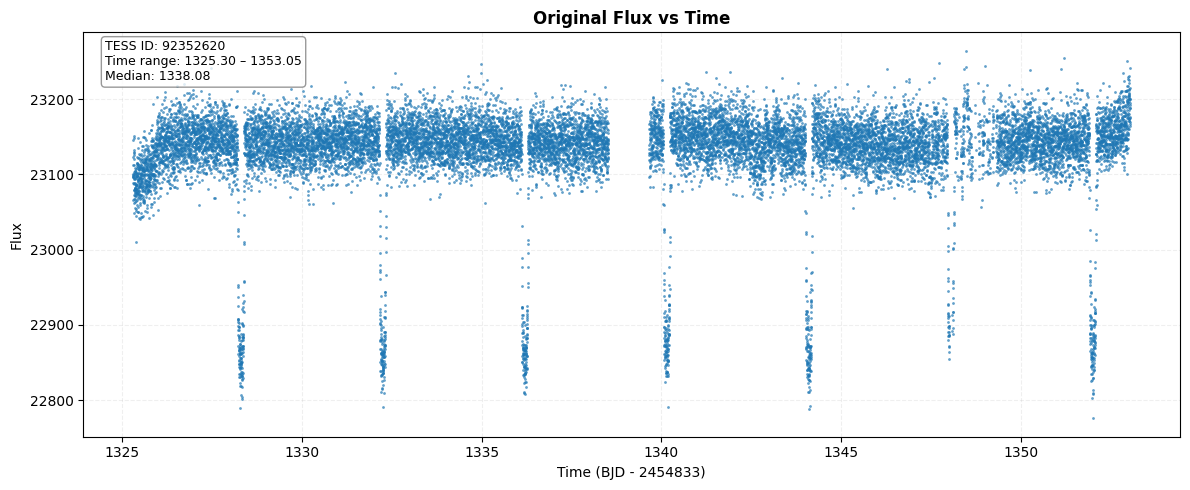

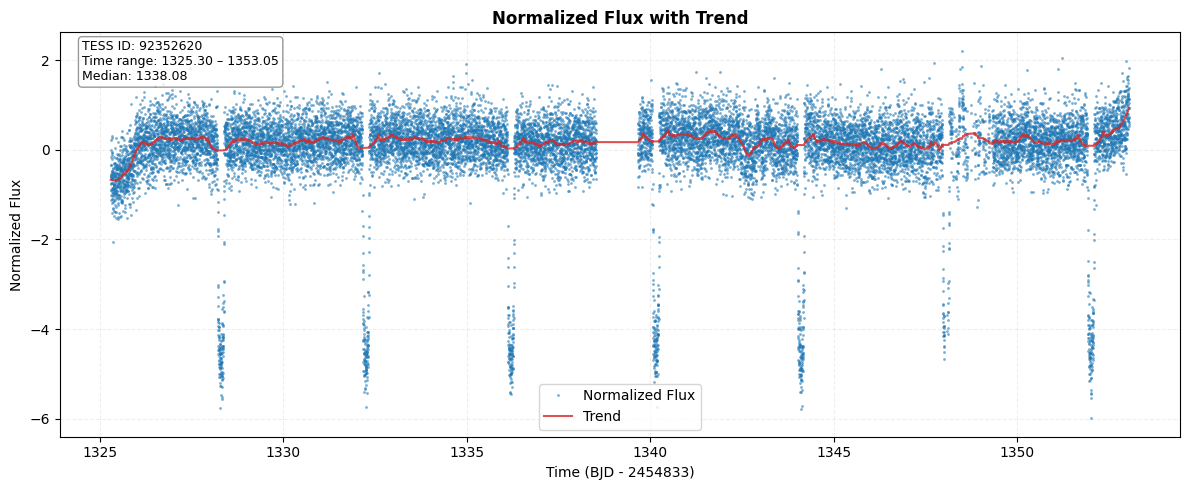

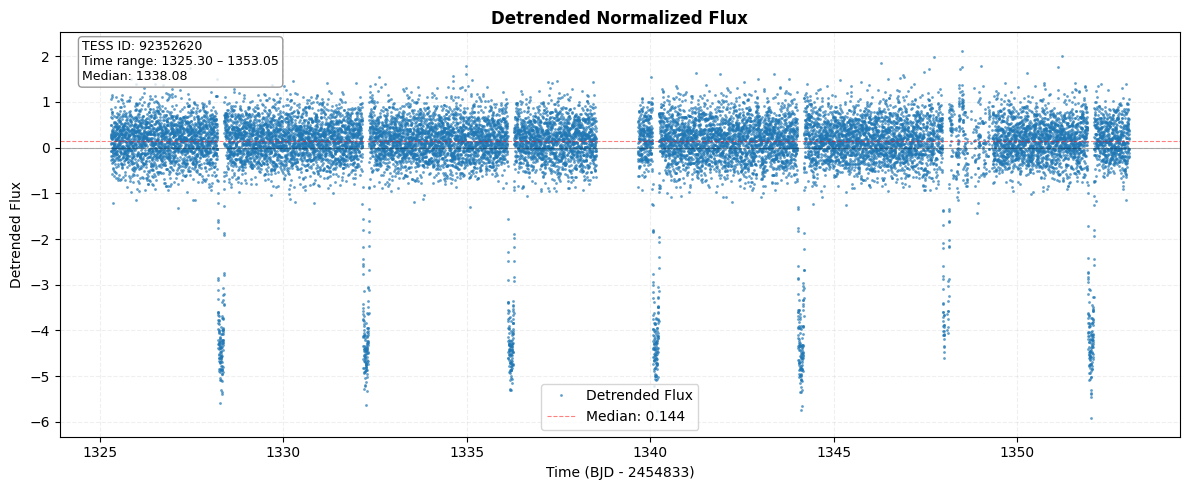

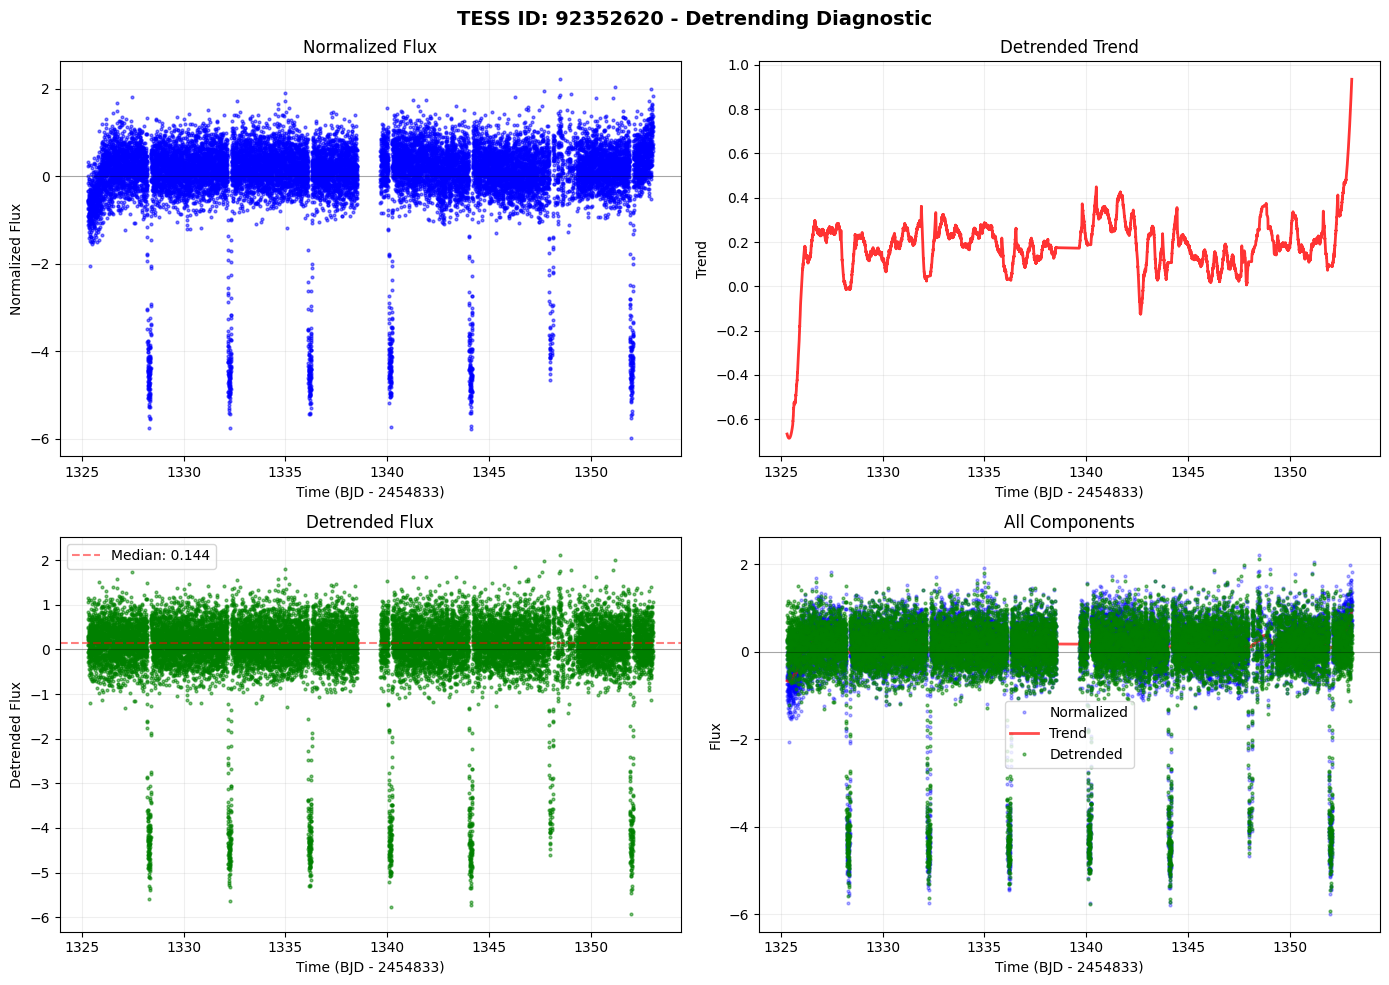


  Detrending Statistics:
    Normalized flux mean: -0.0000
    Normalized flux std: 1.0000
    Detrended flux mean: -0.0099
    Detrended flux std: 0.9697
    Trend median: 0.1879
  Detrending appears successful (mean near 0)
  Displaying automatically centred zoomed transit...


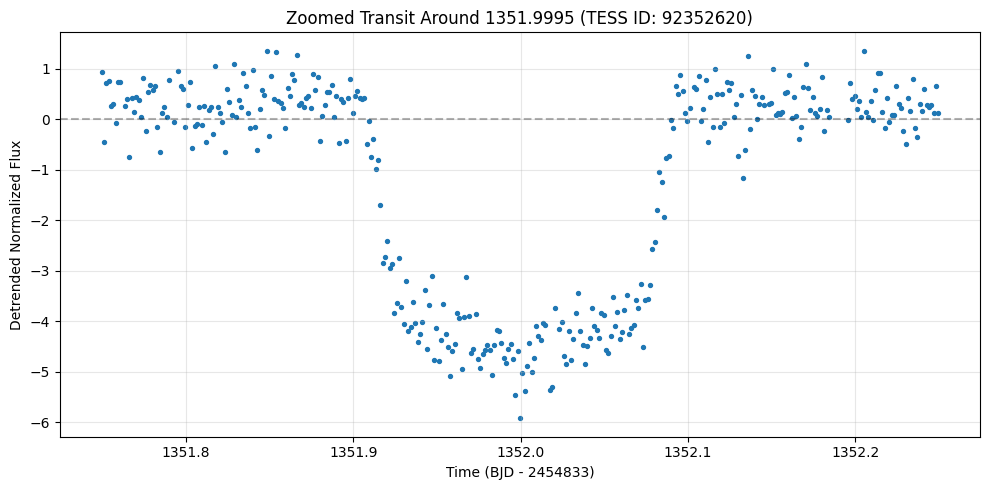


  Please classify this transit:
    [1] Mark as Positive transit
    [2] Mark as Negative transit
    [3] Mark as Uncertain transit
    [4] Skip this data
    [5] Stop the process


  Enter your choice (1-5):  1


  Marked as POSITIVE transit


Processing 2/3: TESS ID: 149603524


  Searching for TIC 149603524 using lightkurve...
  Found 207 sectors for TIC 149603524
  Successfully downloaded data for TIC 149603524
    Points: 18278
    Time range: 1325.30 to 1353.18 (BJD - 2454833)
    Median time: 1338.14
  Normalizing flux...
  Applying detrending...
  Generating plots...


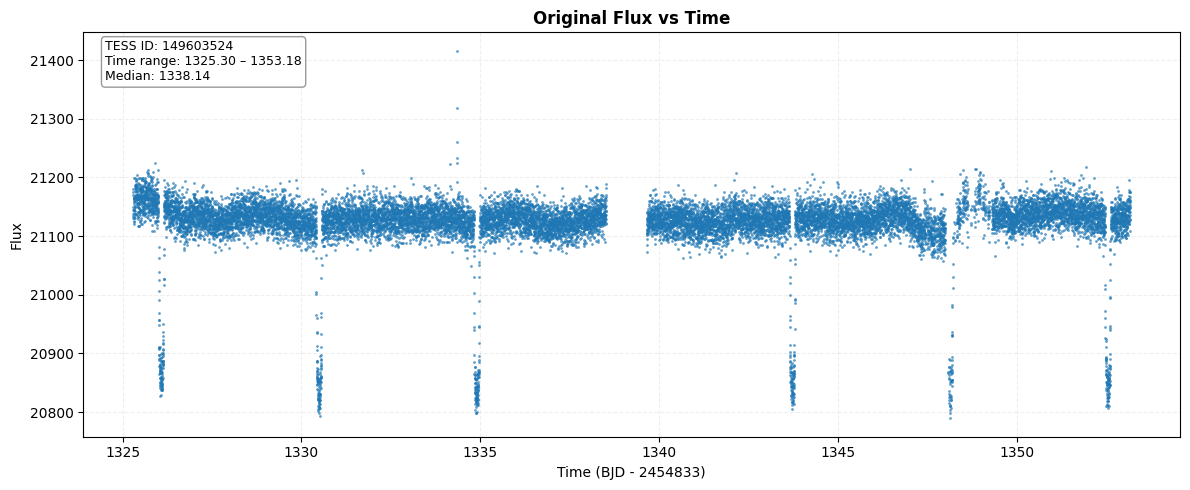

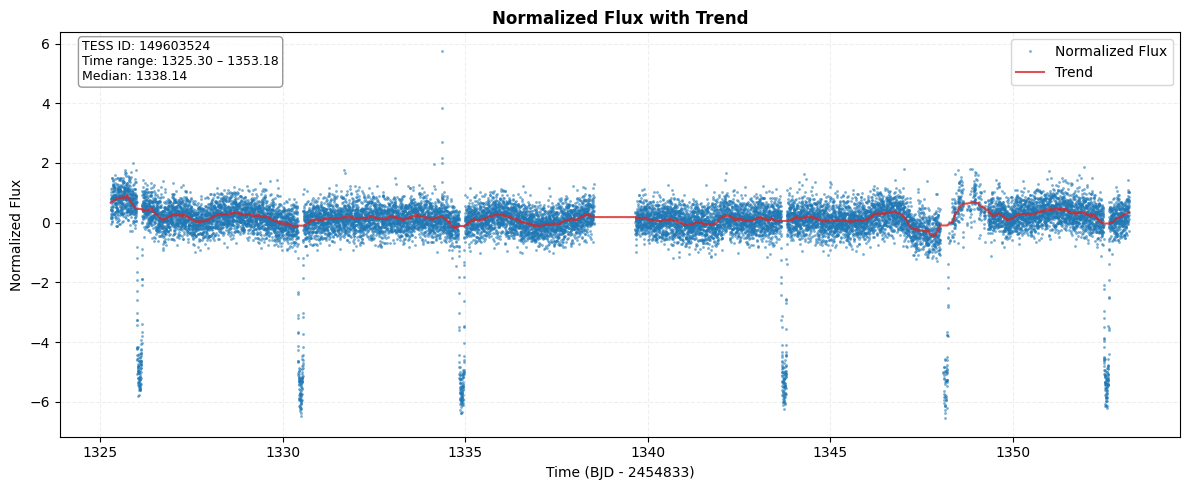

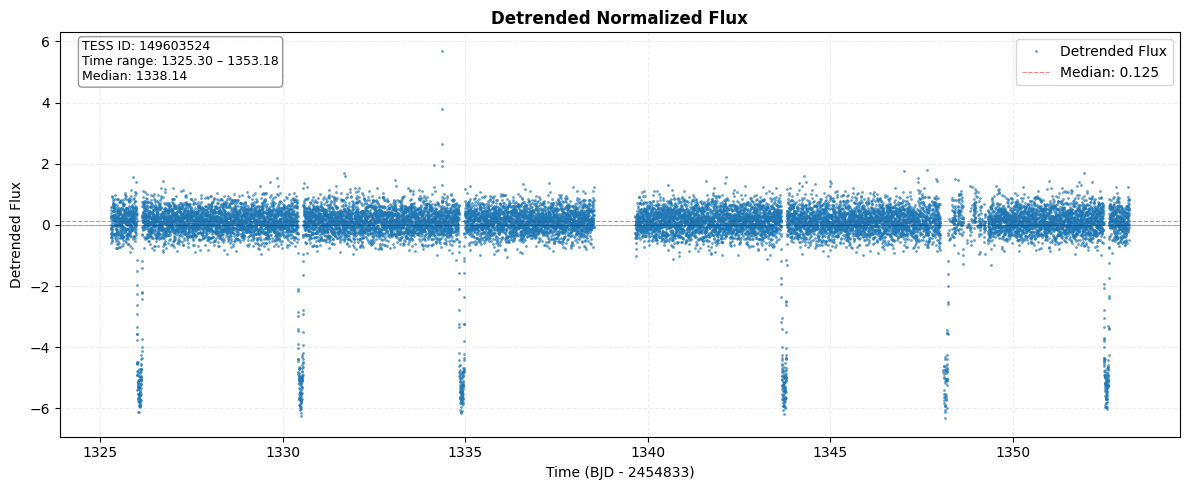

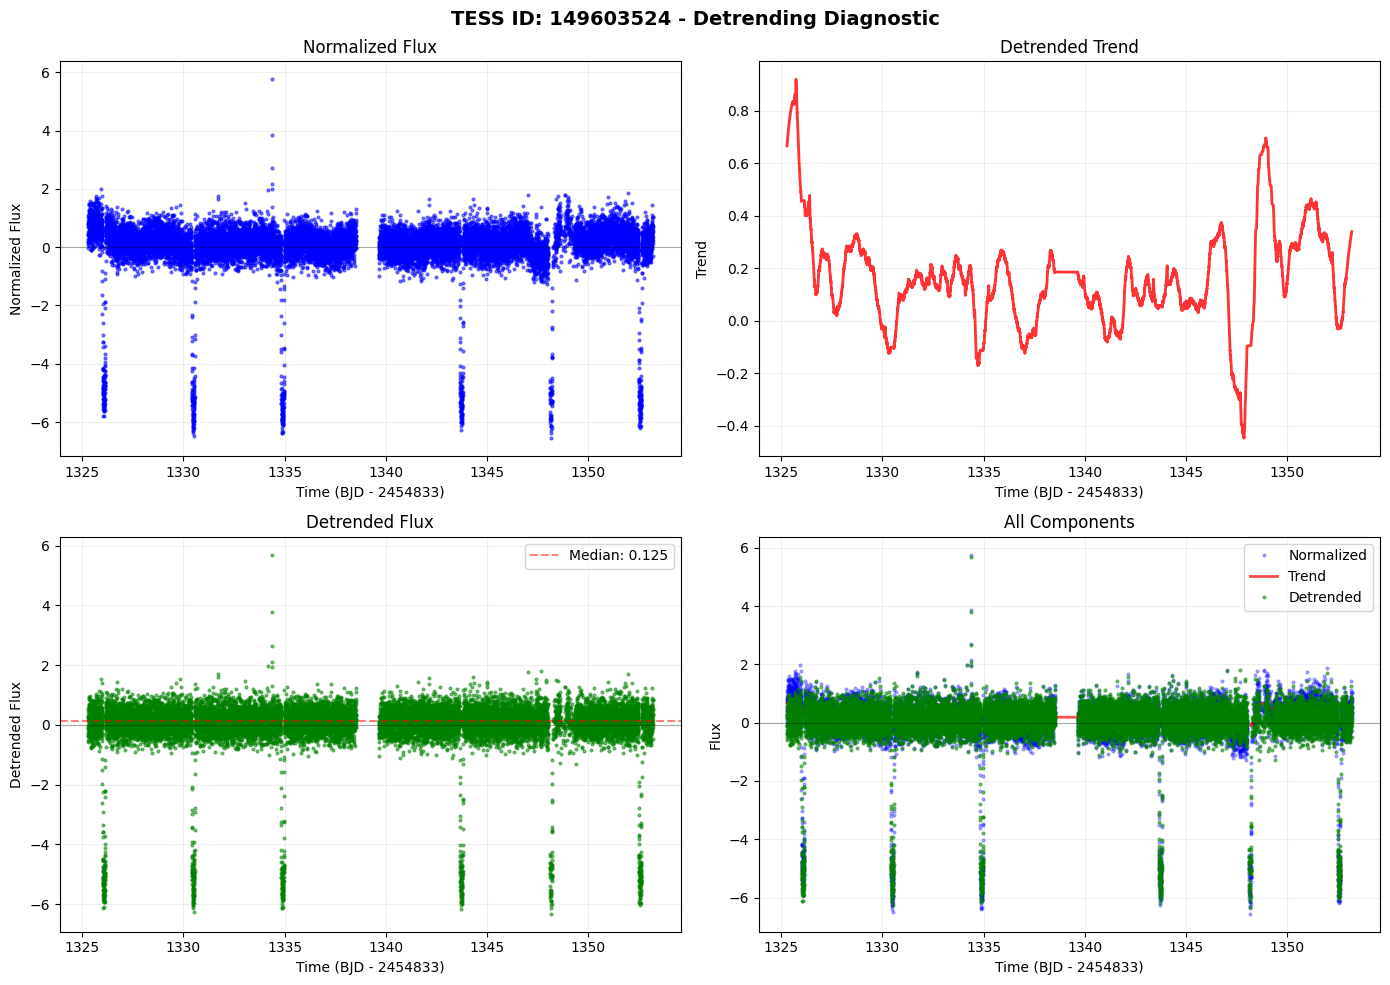


  Detrending Statistics:
    Normalized flux mean: 0.0000
    Normalized flux std: 1.0000
    Detrended flux mean: -0.0162
    Detrended flux std: 0.9645
    Trend median: 0.1397
  Detrending appears successful (mean near 0)
  Displaying automatically centred zoomed transit...


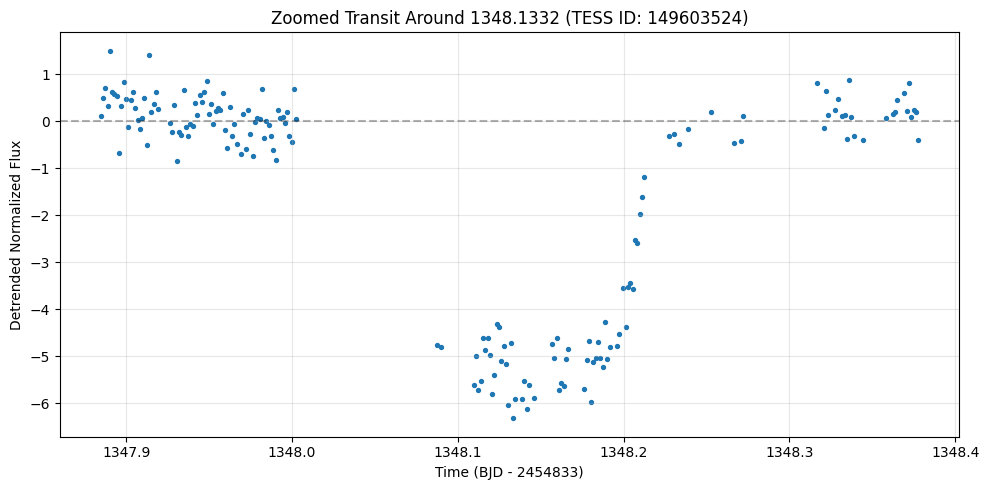


  Please classify this transit:
    [1] Mark as Positive transit
    [2] Mark as Negative transit
    [3] Mark as Uncertain transit
    [4] Skip this data
    [5] Stop the process


  Enter your choice (1-5):  1


  Marked as POSITIVE transit


Processing 3/3: TESS ID: 281541555


  Searching for TIC 281541555 using lightkurve...
  Found 47 sectors for TIC 281541555
  Successfully downloaded data for TIC 281541555
    Points: 18277
    Time range: 1325.30 to 1353.18 (BJD - 2454833)
    Median time: 1338.15
  Normalizing flux...
  Applying detrending...
  Generating plots...


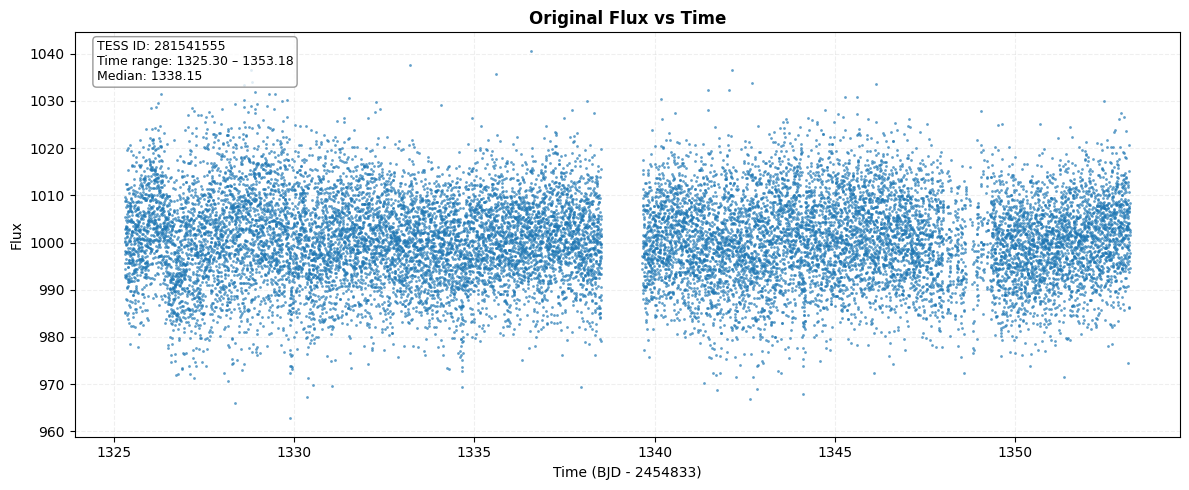

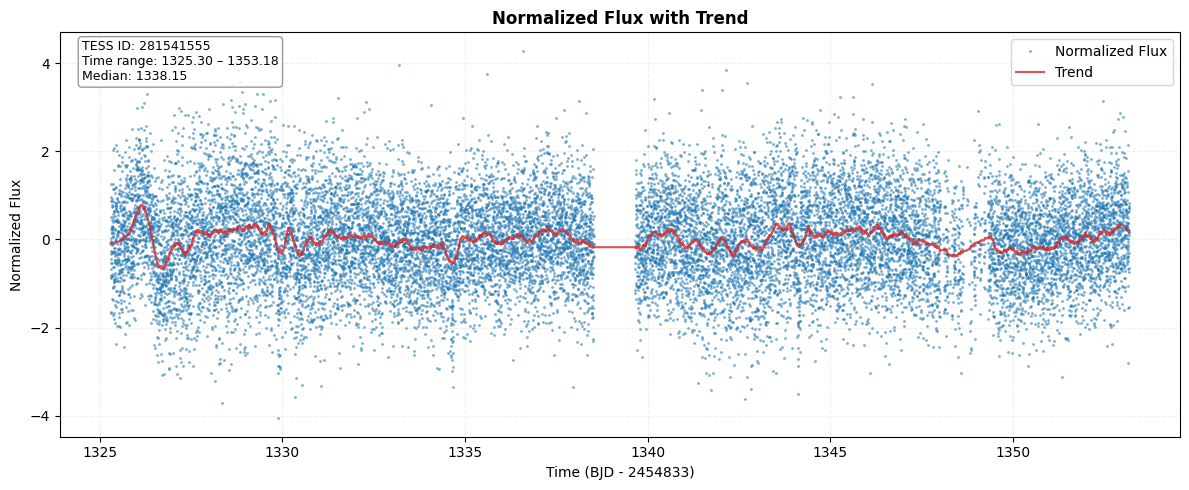

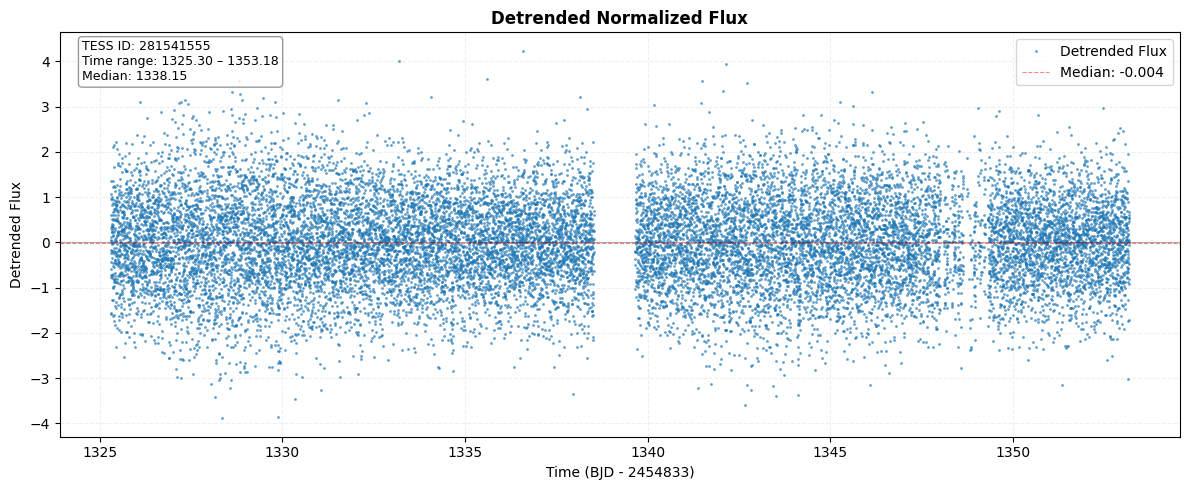

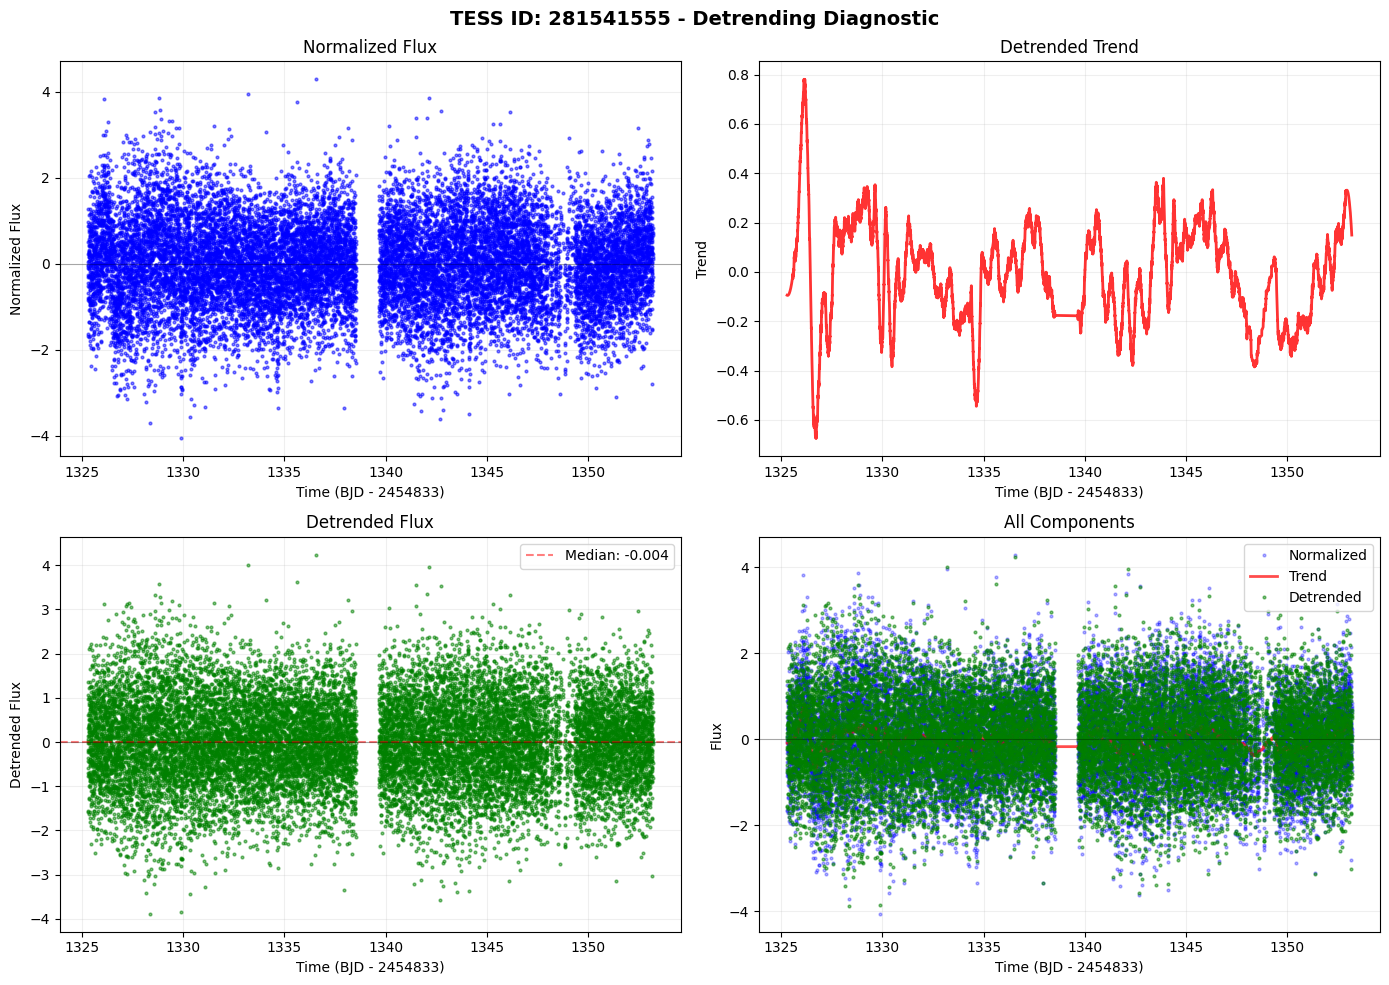


  Detrending Statistics:
    Normalized flux mean: 0.0000
    Normalized flux std: 1.0000
    Detrended flux mean: -0.0039
    Detrended flux std: 0.9760
    Trend median: 0.0089
  Detrending appears successful (mean near 0)
  Displaying automatically centred zoomed transit...


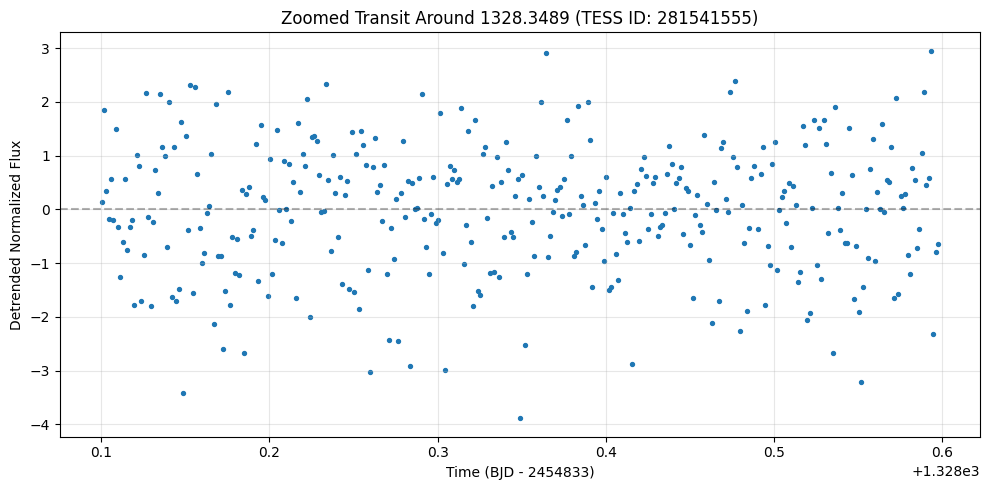


  Please classify this transit:
    [1] Mark as Positive transit
    [2] Mark as Negative transit
    [3] Mark as Uncertain transit
    [4] Skip this data
    [5] Stop the process


  Enter your choice (1-5):  2


  Marked as NEGATIVE transit

Completed processing initial 3 IDs


PROCESSING SUMMARY


Total processed: 3
Positive transits: 2
Negative transits: 1
Uncertain transits: 0
Failed IDs: 1




Currently processed: 3 datasets
Failed IDs: 1

Do you want to:
  [1] Add more data
  [2] Stop the process



Enter your choice (1-2):  2



Process stopped by user.


PROCESSING COMPLETE




In [5]:
if __name__ == "__main__":
    main()